# Projeto 03 — Camada de Ciência de Dados

## Objetivo

Este notebook desenvolve modelos preditivos e exploratórios a partir
da tabela analítica de projetos:

1. Classificação de risco de atraso na data final;
2. Classificação de risco de estouro de orçamento;
3. Regressão para estimar a variação percentual de custo;
4. Clusterização de projetos por perfil de risco.

## Fonte

- `data/processed/project_analytics.csv`

## Critério metodológico

Os modelos supervisionados são treinados somente com projetos
concluídos, pois apenas eles possuem o desfecho real conhecido.

As variáveis utilizadas como preditoras estão disponíveis no
planejamento do projeto e não incluem custos, horas ou datas reais.

In [2]:
# Bibliotecas principais
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
ANALYTICS_FILE = PROCESSED_DIR / "project_analytics.csv"

print("Arquivo de entrada:")
print(ANALYTICS_FILE)

Arquivo de entrada:
/Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/project_analytics.csv


## 1. Carregamento e preparação dos dados

- Carregamos a tabela analítica de projetos gerada pelo notebook 03.
As flags de risco (`schedule_risk_flag` e `cost_risk_flag`) são
validadas, mas não recriadas neste notebook, garantindo que a
definição dos indicadores permaneça centralizada na camada analítica.

- Em seguida, filtramos apenas os projetos concluídos, que possuem
desfechos reais de prazo e custo e formam a base de treinamento dos
modelos supervisionados.

In [4]:
# Carrega a base analítica exportada pelo notebook 03
analytics = pd.read_csv(ANALYTICS_FILE)

# Converte as datas novamente, pois o CSV armazena datas como texto
date_columns = [
    "planned_start_date",
    "planned_end_date",
    "actual_start_date",
    "actual_end_date",
]

for column in date_columns:
    analytics[column] = pd.to_datetime(
        analytics[column],
        errors="coerce",
    )

print("Registros carregados:", len(analytics))
print("Colunas carregadas:", analytics.shape[1])

# Verifica as colunas criadas no notebook 03
required_columns = [
    "is_completed",
    "schedule_risk_flag",
    "cost_risk_flag",
    "end_variance_days",
    "cost_variance_pct",
]

missing_columns = [
    column
    for column in required_columns
    if column not in analytics.columns
]

if missing_columns:
    raise ValueError(
        "Colunas obrigatórias ausentes no project_analytics.csv: "
        f"{missing_columns}"
    )

print("\nColunas obrigatórias encontradas.")

# Filtra projetos concluídos para treinamento
completed = analytics[
    analytics["is_completed"] == True
].copy()

print("Projetos concluídos:", len(completed))

print("\nDistribuição do risco de atraso:")
print(
    completed["schedule_risk_flag"]
    .value_counts(dropna=False)
)

print("\nDistribuição do risco de custo:")
print(
    completed["cost_risk_flag"]
    .value_counts(dropna=False)
)

Registros carregados: 530
Colunas carregadas: 41

Colunas obrigatórias encontradas.
Projetos concluídos: 360

Distribuição do risco de atraso:
schedule_risk_flag
0.0    185
1.0    175
Name: count, dtype: int64

Distribuição do risco de custo:
cost_risk_flag
1.0    220
0.0    140
Name: count, dtype: int64


### Seleção de features

Vamos utilizar como preditores as informações que estão disponíveis
**antes** ou **no início** do projeto — ou seja, características que
não "vazam" o resultado real (evitando data leakage).

- `business_unit`, `project_type`, `priority`, `complexity`
  (categóricas);
- `planned_budget`, `planned_hours`, `team_size`
  (numéricas, definidas no planejamento).

Não usamos `actual_cost`, `actual_hours` ou `actual_end_date` como
preditores, pois essas variáveis só existem depois que o resultado
já aconteceu — usá-las tornaria o modelo inútil na prática.

In [6]:
categorical_features = [
    "business_unit",
    "project_type",
    "priority",
    "complexity",
]

numeric_features = [
    "planned_budget",
    "planned_hours",
    "team_size",
]

features = (
    categorical_features
    + numeric_features
)

model_data = completed.dropna(
    subset=features
).copy()

print(
    "Registros disponíveis para modelagem:",
    len(model_data),
)

print("Features utilizadas:")
print(features)

model_data[features].head()

Registros disponíveis para modelagem: 360
Features utilizadas:
['business_unit', 'project_type', 'priority', 'complexity', 'planned_budget', 'planned_hours', 'team_size']


,business_unit,project_type,priority,complexity,planned_budget,planned_hours,team_size
0,Manufacturing,New Development,Low,Medium,187894.32,1112.9,8
1,Finance,Integration,Critical,Low,42492.02,471.8,3
2,Energy,Consulting,Low,Medium,156426.31,870.5,4
3,Technology,New Development,Low,High,463630.51,2299.3,9
4,Energy,New Development,High,Medium,177604.59,909.7,4


## 2. Pré-processamento

Criamos um pipeline de pré-processamento reutilizável:

- Variáveis categóricas: codificação one-hot;
- Variáveis numéricas: padronização (StandardScaler).

Esse pré-processador será reaproveitado nos três modelos
supervisionados (duas classificações e uma regressão).

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features,
        ),
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
    ]
)

print("Pré-processador configurado.")

Pré-processador configurado.


## 3. Modelo 1 — Classificação de risco de atraso

**Pergunta de negócio:** com base nas características de
planejamento do projeto, é possível prever se ele vai atrasar
(`schedule_risk_flag = 1`)?

Vamos comparar dois modelos:

- Regressão Logística (baseline interpretável);
- Random Forest (modelo não-linear, geralmente mais robusto).

In [10]:
X = model_data[features]

y_schedule = model_data[
    "schedule_risk_flag"
].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_schedule,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_schedule,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição do alvo:")
print(
    y_schedule.value_counts(
        normalize=True
    )
)

Treino: (270, 7)
Teste: (90, 7)

Distribuição do alvo:
schedule_risk_flag
0    0.513889
1    0.486111
Name: proportion, dtype: float64


In [11]:
# Pipeline 1: Regressão Logística
logreg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logreg_pipeline.fit(
    X_train,
    y_train,
)

y_pred_logreg = logreg_pipeline.predict(
    X_test
)

y_proba_logreg = (
    logreg_pipeline
    .predict_proba(X_test)[:, 1]
)

print(
    "=== Regressão Logística — "
    "Risco de Atraso ==="
)

print(
    classification_report(
        y_test,
        y_pred_logreg,
        zero_division=0,
    )
)

print(
    "AUC-ROC:",
    round(
        roc_auc_score(
            y_test,
            y_proba_logreg,
        ),
        3,
    ),
)

=== Regressão Logística — Risco de Atraso ===
              precision    recall  f1-score   support

           0       0.50      0.52      0.51        46
           1       0.48      0.45      0.47        44

    accuracy                           0.49        90
   macro avg       0.49      0.49      0.49        90
weighted avg       0.49      0.49      0.49        90

AUC-ROC: 0.481


In [12]:
# Pipeline 2: Random Forest
rf_schedule_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

rf_schedule_pipeline.fit(
    X_train,
    y_train,
)

y_pred_rf = rf_schedule_pipeline.predict(
    X_test
)

y_proba_rf = (
    rf_schedule_pipeline
    .predict_proba(X_test)[:, 1]
)

print(
    "=== Random Forest — "
    "Risco de Atraso ==="
)

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0,
    )
)

print(
    "AUC-ROC:",
    round(
        roc_auc_score(
            y_test,
            y_proba_rf,
        ),
        3,
    ),
)

=== Random Forest — Risco de Atraso ===
              precision    recall  f1-score   support

           0       0.49      0.52      0.51        46
           1       0.46      0.43      0.45        44

    accuracy                           0.48        90
   macro avg       0.48      0.48      0.48        90
weighted avg       0.48      0.48      0.48        90

AUC-ROC: 0.47


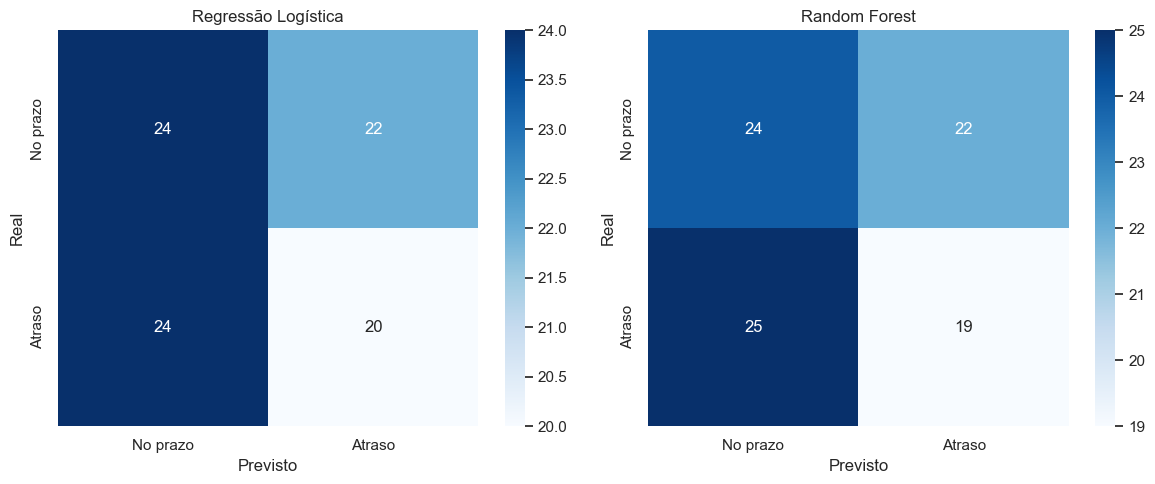

In [13]:
# Matriz de confusão comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_logreg, y_pred_rf],
    ["Regressão Logística", "Random Forest"],
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No prazo", "Atraso"],
        yticklabels=["No prazo", "Atraso"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

> **Insight:** compare o AUC-ROC e o recall da classe "Atraso" entre
> os dois modelos. Em contextos de gestão de risco, geralmente
> priorizamos o **recall** da classe de risco (queremos capturar o
> máximo de projetos que realmente vão atrasar, mesmo que isso gere
> alguns falsos positivos). Se o Random Forest tiver desempenho
> semelhante ou superior à Regressão Logística, ele se torna a
> escolha natural por capturar relações não-lineares entre
> complexidade, orçamento e equipe.

### Importância das variáveis (Random Forest)

Vamos identificar quais características mais influenciam o risco de
atraso, segundo o modelo Random Forest.

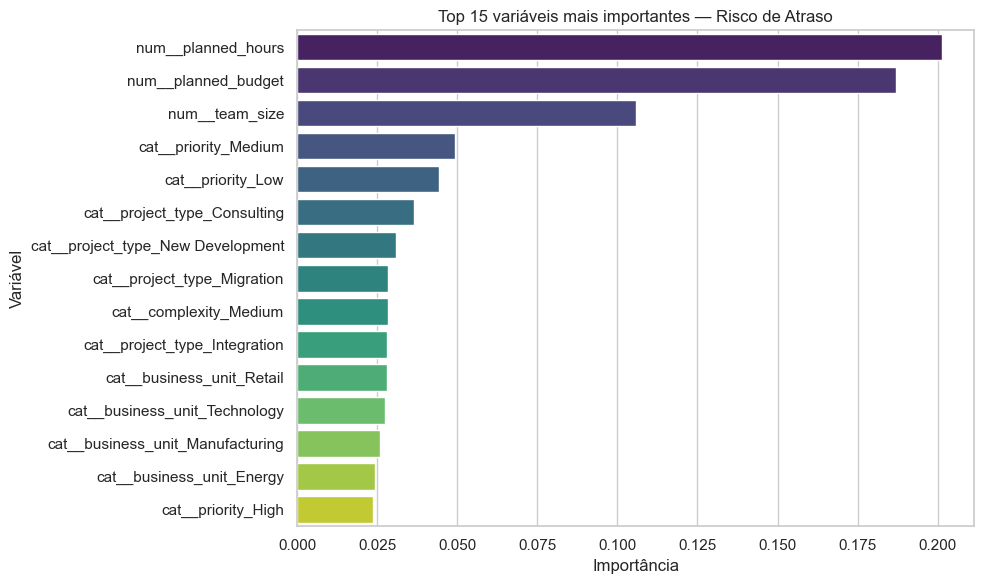

In [16]:
# Extrai os nomes das features após o one-hot encoding
feature_names = (
    rf_schedule_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_schedule_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False,
)
plt.title("Top 15 variáveis mais importantes — Risco de Atraso")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [17]:
importance_df

,feature,importance
20,num__planned_hours,0.201299
19,num__planned_budget,0.186853
21,num__team_size,0.105914
15,cat__priority_Medium,0.049171
14,cat__priority_Low,0.044213
6,cat__project_type_Consulting,0.036553
10,cat__project_type_New Development,0.030701
9,cat__project_type_Migration,0.028448
18,cat__complexity_Medium,0.028444
8,cat__project_type_Integration,0.028125


## 4. Modelo 2 — Classificação de risco de estouro de orçamento

**Pergunta de negócio:** é possível prever, com base no
planejamento, se o projeto vai estourar o orçamento
(`cost_risk_flag = 1`)?

Usaremos o Random Forest como modelo de referência exploratório,
pois ele consegue capturar relações não lineares entre as variáveis
de planejamento. O desempenho será avaliado principalmente pelo
AUC-ROC, recall da classe de estouro e matriz de confusão.

In [19]:
y_cost = model_data[
    "cost_risk_flag"
].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = (
    train_test_split(
        X,
        y_cost,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_cost,
    )
)

rf_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

rf_cost_pipeline.fit(
    X_train_c,
    y_train_c,
)

y_pred_cost = rf_cost_pipeline.predict(
    X_test_c
)

y_proba_cost = (
    rf_cost_pipeline
    .predict_proba(X_test_c)[:, 1]
)

print(
    "=== Random Forest — "
    "Risco de Estouro de Orçamento ==="
)

print(
    classification_report(
        y_test_c,
        y_pred_cost,
        zero_division=0,
    )
)

print(
    "AUC-ROC:",
    round(
        roc_auc_score(
            y_test_c,
            y_proba_cost,
        ),
        3,
    ),
)

=== Random Forest — Risco de Estouro de Orçamento ===
              precision    recall  f1-score   support

           0       0.46      0.49      0.47        35
           1       0.66      0.64      0.65        55

    accuracy                           0.58        90
   macro avg       0.56      0.56      0.56        90
weighted avg       0.58      0.58      0.58        90

AUC-ROC: 0.612


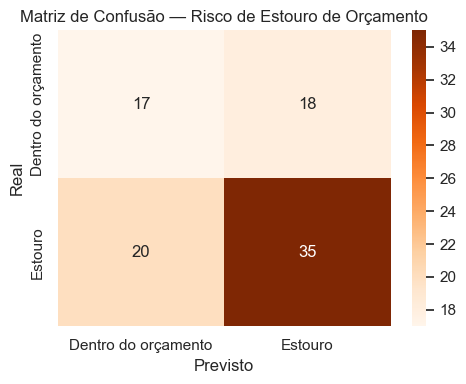

In [20]:
cm_cost = confusion_matrix(y_test_c, y_pred_cost)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_cost,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Dentro do orçamento", "Estouro"],
    yticklabels=["Dentro do orçamento", "Estouro"],
)
plt.title("Matriz de Confusão — Risco de Estouro de Orçamento")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

> **Insight:** aproximadamente 61,1% dos projetos concluídos
> apresentaram estouro de orçamento. O modelo obteve AUC-ROC de
> aproximadamente 0,61, indicando capacidade de discriminação
> limitada, mas superior ao acaso nesta amostra.
>
> Portanto, suas probabilidades devem ser utilizadas como alertas
> preliminares para priorizar revisões de orçamento, escopo e
> capacidade. Elas não devem substituir a avaliação dos gestores.

## 5. Modelo 3 — Regressão para prever `cost_variance_pct`

Além de classificar "estourou ou não", vamos estimar **a magnitude**
do desvio de custo esperado, em percentual sobre o orçamento
planejado.

In [23]:
y_reg = model_data[
    "cost_variance_pct"
].astype(float)

regression_data = model_data.dropna(
    subset=["cost_variance_pct"]
).copy()

X_reg = regression_data[features]
y_reg = regression_data[
    "cost_variance_pct"
]

X_train_r, X_test_r, y_train_r, y_test_r = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.25,
        random_state=RANDOM_STATE,
    )
)

rf_reg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=6,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

rf_reg_pipeline.fit(
    X_train_r,
    y_train_r,
)

y_pred_reg = rf_reg_pipeline.predict(
    X_test_r
)

mae = mean_absolute_error(
    y_test_r,
    y_pred_reg,
)

mse = mean_squared_error(
    y_test_r,
    y_pred_reg,
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_r,
    y_pred_reg,
)

print(
    "=== Random Forest Regressor — "
    "cost_variance_pct ==="
)

print(
    f"MAE:  {mae:.2f} pontos percentuais"
)

print(
    f"RMSE: {rmse:.2f} pontos percentuais"
)

print(
    f"R²:   {r2:.3f}"
)

=== Random Forest Regressor — cost_variance_pct ===
MAE:  15.87 pontos percentuais
RMSE: 19.72 pontos percentuais
R²:   -0.027


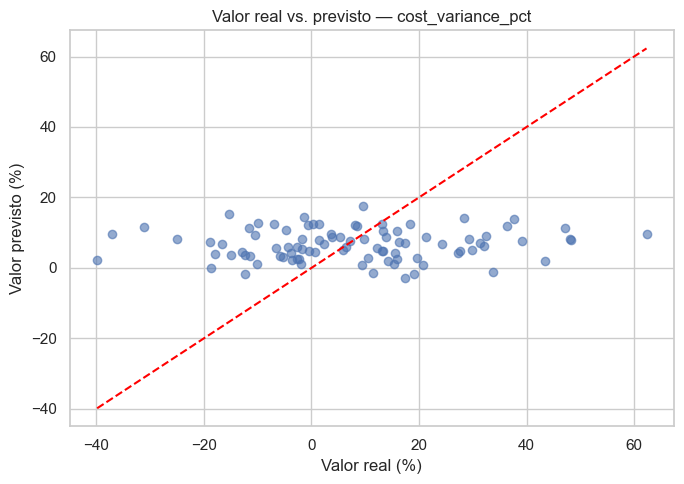

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_r,
    y_pred_reg,
    alpha=0.6,
)

min_value = min(
    y_test_r.min(),
    y_pred_reg.min(),
)

max_value = max(
    y_test_r.max(),
    y_pred_reg.max(),
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
)

plt.title(
    "Valor real vs. previsto — "
    "cost_variance_pct"
)

plt.xlabel("Valor real (%)")
plt.ylabel("Valor previsto (%)")
plt.tight_layout()
plt.show()

> **Insight:** o R² indica o quanto da variação do desvio de custo
> conseguimos explicar apenas com informações de planejamento. Um R²
> baixo (por exemplo, abaixo de 0,3) sugere que o desvio de custo
> depende fortemente de fatores não capturados nos dados (execução,
> fornecedores, mudanças de escopo), o que por si só já é um insight
> de negócio importante: **o desvio de custo pode não ser
> previsível apenas pelo planejamento inicial**, reforçando a
> necessidade de acompanhamento contínuo durante a execução.

## 6. Clusterização por perfil de risco

A clusterização será realizada somente com projetos concluídos,
pois as variáveis de desempenho real — prazo, custo e qualidade —
não estão disponíveis para projetos ainda em execução.

Os clusters não representam níveis absolutos de risco. Seus rótulos
são definidos posteriormente pela interpretação das médias de cada
grupo.

In [27]:
cluster_features = [
    "start_variance_days",
    "end_variance_days",
    "cost_variance_pct",
    "hours_variance_pct",
    "final_quality_score",
]

cluster_data = completed.dropna(
    subset=cluster_features
).copy()

print(
    "Projetos disponíveis para clusterização:",
    len(cluster_data),
)

scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(
    cluster_data[cluster_features]
)

Projetos disponíveis para clusterização: 360


### Escolha do número de clusters (método do cotovelo)

Antes de definir o número final de clusters, avaliamos a inércia
para diferentes valores de k.

In [29]:
# Avaliação sistemática do número de clusters
cluster_evaluation = []

k_range = range(2, 9)

for k in k_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )

    labels_temp = kmeans_temp.fit_predict(X_cluster)

    cluster_evaluation.append({
        "n_clusters": k,
        "inertia": kmeans_temp.inertia_,
        "silhouette_score": silhouette_score(
            X_cluster,
            labels_temp,
        ),
    })

cluster_evaluation_df = pd.DataFrame(
    cluster_evaluation
)

display(cluster_evaluation_df)

,n_clusters,inertia,silhouette_score
0,2,1375.945240,0.229787
1,3,1199.988745,0.187091
2,4,1066.580397,0.188589
3,5,969.197550,0.191908
4,6,879.424019,0.188011
5,7,812.454788,0.191264
6,8,761.441245,0.189633


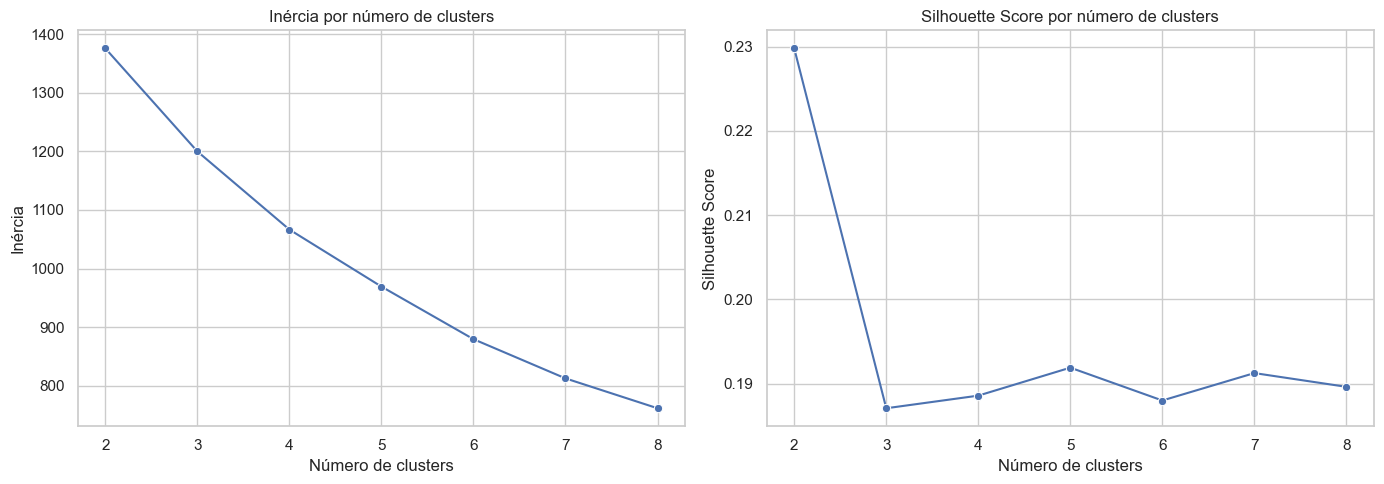

In [30]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

sns.lineplot(
    data=cluster_evaluation_df,
    x="n_clusters",
    y="inertia",
    marker="o",
    ax=axes[0],
)

axes[0].set_title(
    "Inércia por número de clusters"
)

axes[0].set_xlabel(
    "Número de clusters"
)

axes[0].set_ylabel(
    "Inércia"
)

sns.lineplot(
    data=cluster_evaluation_df,
    x="n_clusters",
    y="silhouette_score",
    marker="o",
    ax=axes[1],
)

axes[1].set_title(
    "Silhouette Score por número de clusters"
)

axes[1].set_xlabel(
    "Número de clusters"
)

axes[1].set_ylabel(
    "Silhouette Score"
)

plt.tight_layout()
plt.show()

In [31]:
# escolher automaticamente o melhor valor segundo a separação estatística

best_k_by_silhouette = int(
    cluster_evaluation_df.loc[
        cluster_evaluation_df["silhouette_score"].idxmax(),
        "n_clusters",
    ]
)

best_silhouette = cluster_evaluation_df.loc[
    cluster_evaluation_df["silhouette_score"].idxmax(),
    "silhouette_score",
]

print(
    "Melhor k pelo Silhouette Score:",
    best_k_by_silhouette,
)

print(
    "Melhor Silhouette Score:",
    round(best_silhouette, 3),
)

Melhor k pelo Silhouette Score: 2
Melhor Silhouette Score: 0.23


In [32]:
# Se a diferença entre o melhor k e k=4 for pequena,
# preservamos k=4 por interpretabilidade.
silhouette_k4 = cluster_evaluation_df.loc[
    cluster_evaluation_df["n_clusters"] == 4,
    "silhouette_score",
].iloc[0]

if best_silhouette - silhouette_k4 <= 0.02:
    N_CLUSTERS = 4
else:
    N_CLUSTERS = best_k_by_silhouette

print(
    "Número de clusters selecionado:",
    N_CLUSTERS,
)

Número de clusters selecionado: 2


In [33]:
# Treinamento final da clusterização
# A coluna risk_cluster precisa existir antes dos gráficos.

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20,
)

cluster_data["risk_cluster"] = (
    kmeans.fit_predict(X_cluster)
)

# Avaliação final da separação dos clusters
silhouette = silhouette_score(
    X_cluster,
    cluster_data["risk_cluster"],
)

print(
    f"Silhouette Score final "
    f"(k={N_CLUSTERS}): {silhouette:.3f}"
)

Silhouette Score final (k=2): 0.230


In [34]:
# Resumo dos clusters
cluster_summary = (
    cluster_data
    .groupby("risk_cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_summary["n_projects"] = (
    cluster_data["risk_cluster"]
    .value_counts()
)

cluster_summary = cluster_summary.sort_index()

display(cluster_summary)

# Perfil exploratório dos clusters
def classify_cluster(row):
    if (
        row["end_variance_days"] > 0
        and row["cost_variance_pct"] > 0
    ):
        return "Risco combinado de prazo e custo"

    if row["end_variance_days"] > 0:
        return "Risco predominante de prazo"

    if row["cost_variance_pct"] > 0:
        return "Risco predominante de custo"

    return "Desempenho controlado"


cluster_summary["cluster_profile"] = (
    cluster_summary.apply(
        classify_cluster,
        axis=1,
    )
)

display(cluster_summary)

,start_variance_days,end_variance_days,cost_variance_pct,hours_variance_pct,final_quality_score,n_projects
risk_cluster,,,,,,
0,3.84,6.82,22.93,5.01,7.82,153
1,2.74,-5.17,-4.52,4.20,8.47,207


,start_variance_days,end_variance_days,cost_variance_pct,hours_variance_pct,final_quality_score,n_projects,cluster_profile
risk_cluster,,,,,,,
0,3.84,6.82,22.93,5.01,7.82,153,Risco combinado de prazo e custo
1,2.74,-5.17,-4.52,4.20,8.47,207,Desempenho controlado


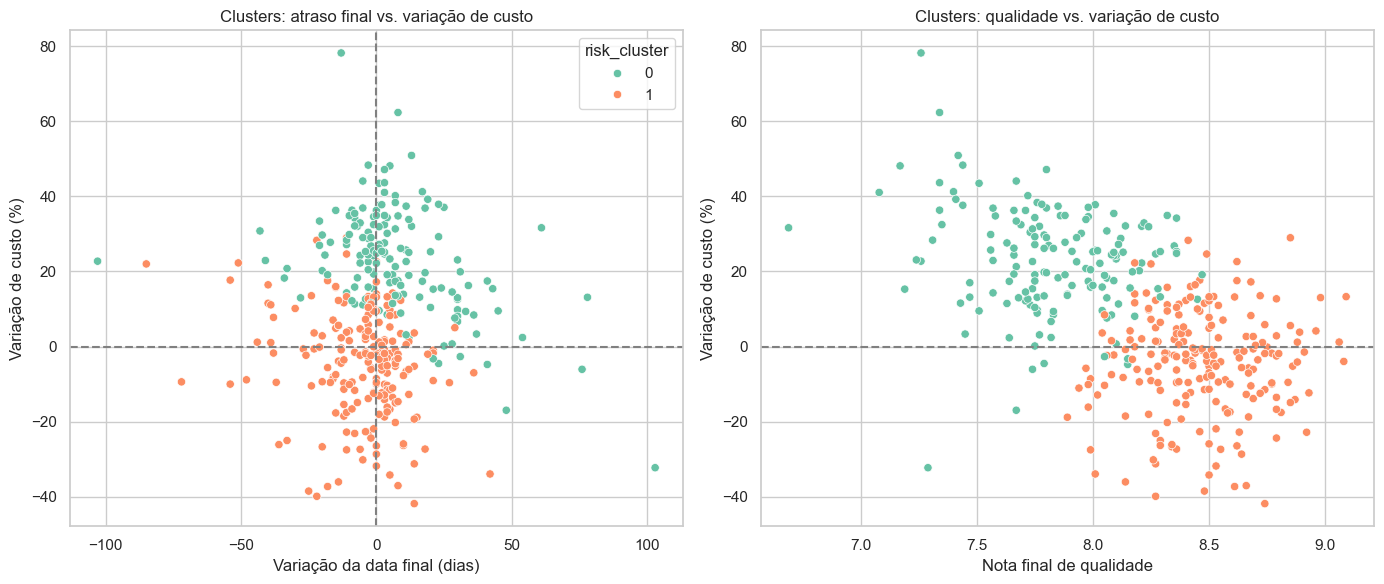

In [35]:
# Gráficos dos clusters
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

sns.scatterplot(
    data=cluster_data,
    x="end_variance_days",
    y="cost_variance_pct",
    hue="risk_cluster",
    palette="Set2",
    ax=axes[0],
)

axes[0].axvline(
    0,
    color="gray",
    linestyle="--",
)

axes[0].axhline(
    0,
    color="gray",
    linestyle="--",
)

axes[0].set_title(
    "Clusters: atraso final vs. variação de custo"
)

axes[0].set_xlabel(
    "Variação da data final (dias)"
)

axes[0].set_ylabel(
    "Variação de custo (%)"
)

sns.scatterplot(
    data=cluster_data,
    x="final_quality_score",
    y="cost_variance_pct",
    hue="risk_cluster",
    palette="Set2",
    legend=False,
    ax=axes[1],
)

axes[1].axhline(
    0,
    color="gray",
    linestyle="--",
)

axes[1].set_title(
    "Clusters: qualidade vs. variação de custo"
)

axes[1].set_xlabel(
    "Nota final de qualidade"
)

axes[1].set_ylabel(
    "Variação de custo (%)"
)

plt.tight_layout()
plt.show()

> **Insight:** observe os valores médios de cada cluster na tabela
> `cluster_summary`. Normalmente emergem perfis como:
>
> - **Cluster de alta performance**: baixo desvio de prazo e custo,
>   alta qualidade;
> - **Cluster de risco de custo**: alto `cost_variance_pct`,
>   independentemente do prazo;
> - **Cluster de risco de prazo**: alto `schedule_variance_days`,
>   custo controlado;
> - **Cluster crítico**: desvios altos em ambas as dimensões.
>
> Esses perfis podem ser usados para **priorizar auditoria e
> governança**, focando esforço de gestão nos projetos com maior
> probabilidade de pertencer aos clusters de risco.

## 7. Scoring da carteira completa

Após o treinamento com projetos concluídos, aplicamos os modelos
aos projetos concluídos e não concluídos que possuem as features de
planejamento necessárias.

As probabilidades geradas são alertas analíticos, não decisões
definitivas. O modelo de atraso apresentou desempenho limitado na
primeira avaliação e deve ser interpretado com cautela.

In [38]:
# Aplica os modelos de classificação e regressão a todos os projetos
# (concluídos e não concluídos), desde que tenham as features completas
scoring_data = analytics.dropna(
    subset=features
).copy()

X_score = scoring_data[features]

scoring_data[
    "predicted_schedule_risk_proba"
] = (
    rf_schedule_pipeline
    .predict_proba(X_score)[:, 1]
)

scoring_data[
    "predicted_cost_risk_proba"
] = (
    rf_cost_pipeline
    .predict_proba(X_score)[:, 1]
)

scoring_data[
    "predicted_cost_variance_pct"
] = (
    rf_reg_pipeline
    .predict(X_score)
)

print(
    "Projetos com score calculado:",
    len(scoring_data),
)

scoring_data[
    [
        "project_id",
        "project_status",
        "predicted_schedule_risk_proba",
        "predicted_cost_risk_proba",
        "predicted_cost_variance_pct",
    ]
].head(10)

Projetos com score calculado: 530


,project_id,project_status,predicted_schedule_risk_proba,predicted_cost_risk_proba,predicted_cost_variance_pct
0,P0001,Completed,0.222857,0.511738,3.523307
1,P0002,Completed,0.628632,0.464783,8.270467
2,P0003,Completed,0.187386,0.371517,-7.307174
3,P0004,Completed,0.351722,0.579637,12.554780
4,P0005,Completed,0.317018,0.364869,3.572942
5,P0006,Completed,0.628743,0.555608,8.979047
6,P0007,Completed,0.327608,0.680093,8.953746
7,P0008,Completed,0.434764,0.588188,4.584906
8,P0009,Completed,0.469512,0.786832,10.217530
9,P0010,On Hold,0.539022,0.535697,4.865369


In [39]:
# Criar níveis interpretáveis de risco

def classify_risk(probability):
    if probability >= 0.70:
        return "Alto"
    elif probability >= 0.40:
        return "Moderado"
    else:
        return "Baixo"


scoring_data[
    "schedule_risk_level"
] = scoring_data[
    "predicted_schedule_risk_proba"
].apply(classify_risk)

scoring_data[
    "cost_risk_level"
] = scoring_data[
    "predicted_cost_risk_proba"
].apply(classify_risk)

scoring_data[
    "predicted_cost_variance_band"
] = pd.cut(
    scoring_data[
        "predicted_cost_variance_pct"
    ],
    bins=[
        -np.inf,
        0,
        10,
        25,
        np.inf,
    ],
    labels=[
        "Dentro do orçamento",
        "Estouro baixo",
        "Estouro moderado",
        "Estouro alto",
    ],
)

scoring_data[
    [
        "project_id",
        "schedule_risk_level",
        "cost_risk_level",
        "predicted_cost_variance_band",
    ]
].head()

,project_id,schedule_risk_level,cost_risk_level,predicted_cost_variance_band
0,P0001,Baixo,Moderado,Estouro baixo
1,P0002,Moderado,Moderado,Estouro baixo
2,P0003,Baixo,Baixo,Dentro do orçamento
3,P0004,Baixo,Moderado,Estouro moderado
4,P0005,Baixo,Baixo,Estouro baixo


In [40]:
# Remove colunas de um merge anterior, se existirem
scoring_data = scoring_data.drop(
    columns=[
        col
        for col in [
            "risk_cluster",
            "risk_cluster_x",
            "risk_cluster_y",
            "cluster_profile",
        ]
        if col in scoring_data.columns
    ]
)

# Recria o cluster_export do zero
cluster_export = cluster_data[
    [
        "project_id",
        "risk_cluster",
    ]
].copy()

cluster_profile_export = (
    cluster_summary[
        ["cluster_profile"]
    ]
    .reset_index()
)

cluster_export = cluster_export.merge(
    cluster_profile_export,
    on="risk_cluster",
    how="left",
)

scoring_data = scoring_data.merge(
    cluster_export,
    on="project_id",
    how="left",
)

print(
    "Projetos com cluster atribuído:",
    scoring_data["risk_cluster"]
    .notna()
    .sum(),
)

print(
    "Projetos com perfil de cluster:",
    scoring_data["cluster_profile"]
    .notna()
    .sum(),
)

Projetos com cluster atribuído: 360
Projetos com perfil de cluster: 360


In [41]:
# Exportar o resultado final

risk_scores_path = (
    PROCESSED_DIR
    / "project_risk_scores.csv"
)

scoring_data.to_csv(
    risk_scores_path,
    index=False,
)

print(
    "Arquivo exportado com sucesso:"
)

print(risk_scores_path)

print(
    "\nDimensão final:",
    scoring_data.shape,
)

Arquivo exportado com sucesso:
/Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/project_risk_scores.csv

Dimensão final: (530, 49)


In [42]:
# Validação final do arquivo de scores

final_columns = [
    "project_id",
    "project_status",
    "predicted_schedule_risk_proba",
    "predicted_cost_risk_proba",
    "predicted_cost_variance_pct",
    "predicted_cost_variance_band",
    "schedule_risk_level",
    "cost_risk_level",
    "risk_cluster",
    "cluster_profile",
]

missing_final_columns = [
    column
    for column in final_columns
    if column not in scoring_data.columns
]

if missing_final_columns:
    raise ValueError(
        "Colunas finais ausentes: "
        f"{missing_final_columns}"
    )

# Quantidade total de projetos
assert len(scoring_data) == 530, (
    "O arquivo final deve conter 530 projetos."
)

# Identificadores únicos
assert (
    scoring_data["project_id"].nunique()
    == 530
), (
    "A quantidade de project_id únicos deve ser 530."
)

# Ausência de duplicação de projetos
assert not scoring_data["project_id"].duplicated().any(), (
    "Existem project_id duplicados."
)

# Validação das probabilidades
assert scoring_data[
    "predicted_schedule_risk_proba"
].between(0, 1).all(), (
    "Probabilidade de atraso fora do intervalo [0, 1]."
)

assert scoring_data[
    "predicted_cost_risk_proba"
].between(0, 1).all(), (
    "Probabilidade de custo fora do intervalo [0, 1]."
)

# Validação da clusterização
projects_with_cluster = (
    scoring_data["risk_cluster"]
    .notna()
    .sum()
)

projects_without_cluster = (
    scoring_data["risk_cluster"]
    .isna()
    .sum()
)

projects_with_profile = (
    scoring_data["cluster_profile"]
    .notna()
    .sum()
)

projects_without_profile = (
    scoring_data["cluster_profile"]
    .isna()
    .sum()
)

assert projects_with_cluster == 360, (
    "Deveriam existir 360 projetos com cluster."
)

assert projects_without_cluster == 170, (
    "Deveriam existir 170 projetos sem cluster."
)

assert projects_with_profile == 360, (
    "Deveriam existir 360 projetos com perfil de cluster."
)

assert projects_without_profile == 170, (
    "Deveriam existir 170 projetos sem perfil de cluster."
)

# Reexporta somente após todas as validações
scoring_data.to_csv(
    risk_scores_path,
    index=False,
)

print("Validação final concluída.")
print("Linhas:", len(scoring_data))
print("Colunas:", scoring_data.shape[1])
print(
    "Projetos únicos:",
    scoring_data["project_id"].nunique(),
)
print(
    "Projetos com cluster:",
    projects_with_cluster,
)
print(
    "Projetos sem cluster:",
    projects_without_cluster,
)
print(
    "Projetos com perfil de cluster:",
    projects_with_profile,
)
print(
    "Projetos sem perfil de cluster:",
    projects_without_profile,
)
print(
    "Arquivo exportado:",
    risk_scores_path,
)

Validação final concluída.
Linhas: 530
Colunas: 49
Projetos únicos: 530
Projetos com cluster: 360
Projetos sem cluster: 170
Projetos com perfil de cluster: 360
Projetos sem perfil de cluster: 170
Arquivo exportado: /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/project_risk_scores.csv


In [43]:
from pathlib import Path

print("Diretório atual do kernel:", Path.cwd())

Diretório atual do kernel: /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/notebooks


In [44]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

output_path = PROCESSED_DIR / "project_risk_scores.csv"

print("Caminho usado:", output_path)
print("Arquivo existe?", output_path.exists())

final_df = pd.read_csv(output_path)

print("Linhas:", len(final_df))
print("Colunas:", final_df.shape[1])
print(
    "Projetos únicos:",
    final_df["project_id"].nunique(),
)

Caminho usado: /Users/dtp/Desktop/projetos_BI/projeto-03-project-portfolio-management/data/processed/project_risk_scores.csv
Arquivo existe? True
Linhas: 530
Colunas: 49
Projetos únicos: 530


In [45]:
print("\nColunas finais:")
print(final_df.columns.tolist())

print("\nClusters:")
print(
    final_df["risk_cluster"]
    .value_counts(dropna=False)
)

print("\nPerfis:")
print(
    final_df["cluster_profile"]
    .value_counts(dropna=False)
)


Colunas finais:
['project_id', 'project_name', 'client_id', 'project_manager', 'business_unit', 'project_type', 'priority', 'complexity', 'planned_start_date', 'planned_end_date', 'actual_start_date', 'actual_end_date', 'planned_budget', 'actual_cost', 'planned_hours', 'actual_hours', 'team_size', 'project_status', 'final_quality_score', 'client_satisfaction_score', 'planned_duration_days', 'actual_duration_days', 'schedule_variance_days', 'start_variance_days', 'end_variance_days', 'cost_variance', 'cost_variance_pct', 'hours_variance', 'hours_variance_pct', 'is_completed', 'is_cancelled', 'is_active_current', 'is_pipeline', 'schedule_risk_flag', 'cost_risk_flag', 'completed_on_time', 'completed_within_budget', 'quality_band', 'start_year', 'start_month', 'start_month_name', 'predicted_schedule_risk_proba', 'predicted_cost_risk_proba', 'predicted_cost_variance_pct', 'schedule_risk_level', 'cost_risk_level', 'predicted_cost_variance_band', 'risk_cluster', 'cluster_profile']

Clusters:

## 8. Síntese de insights — Camada de Ciência de Dados

### Risco de atraso

Os modelos de risco de atraso apresentaram desempenho próximo ao
aleatório, com AUC-ROC inferior a 0,50 nesta amostra. Portanto,
as probabilidades de atraso devem ser tratadas como scores
exploratórios, e não como previsões confiáveis.

O resultado indica que as variáveis de planejamento disponíveis —
unidade de negócio, tipo, prioridade, complexidade, orçamento,
horas planejadas e tamanho da equipe — não explicam suficientemente
o atraso na data final.

Para melhorar esse modelo, seria necessário incorporar variáveis de
execução, como progresso, bloqueios, mudanças de escopo,
dependências, replanejamentos e disponibilidade de recursos.

### Risco de custo

O modelo de estouro de orçamento apresentou o melhor resultado
supervisionado, com AUC-ROC de aproximadamente 0,62. Isso indica
algum poder de discriminação, embora ainda limitado.

O score pode ser utilizado como alerta preliminar para priorizar
revisões de orçamento, escopo e capacidade, mas não deve substituir
a análise dos gestores.

### Regressão de custo

O modelo de regressão apresentou MAE de aproximadamente 15,87 pontos
percentuais e R² negativo. Isso indica que as variáveis de
planejamento utilizadas não explicam adequadamente a magnitude do
desvio de custo.

A coluna `predicted_cost_variance_pct` deve ser interpretada como
uma estimativa exploratória, e não como uma previsão precisa.

### Clusterização

A clusterização foi utilizada para segmentar historicamente os
projetos concluídos. O melhor resultado foi obtido com dois clusters,
com Silhouette Score de aproximadamente 0,23.

Esse valor indica separação fraca a moderada entre os grupos, com
sobreposição relevante. Portanto, os clusters devem ser interpretados
como perfis exploratórios de desempenho histórico, e não como níveis
definitivos de risco.

### Exportação

O arquivo `project_risk_scores.csv` foi gerado com 530 projetos e
consolida:

- Dados analíticos dos projetos;
- Probabilidade exploratória de atraso;
- Probabilidade exploratória de estouro de orçamento;
- Estimativa exploratória de variação de custo;
- Níveis interpretáveis de risco;
- Cluster histórico dos projetos concluídos;
- Perfil interpretativo associado a cada cluster histórico.

Esses resultados podem alimentar o dashboard React + Vite, desde que
os scores preditivos sejam apresentados como indicadores exploratórios,
com indicação clara de suas limitações estatísticas.

Os projetos não concluídos recebem scores baseados nas informações de
planejamento disponíveis, mas não recebem cluster ou perfil histórico,
pois ainda não possuem desfecho real de prazo, custo e qualidade.